In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
from typing import Optional, Tuple, Any
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 1. Kaggle Veri Seçimi/İndirme (Data Acquisition)
class KaggleDataLoader:
    """Handles data downloading from Kaggle and local loading."""
    def __init__(self, dataset_name: str, file_name: str):
        self.dataset_name = dataset_name
        self.file_name = file_name
        self.data_dir = 'data'

    def download_data(self) -> Optional[pd.DataFrame]:
        """Downloads dataset using Kaggle API."""
        logger.info(f"Attempting to download {self.file_name} from {self.dataset_name}...")
        try:
            os.makedirs(self.data_dir, exist_ok=True)
            # Uncomment below when Kaggle API is configured
            # os.system(f'kaggle datasets download -d {self.dataset_name} -p {self.data_dir} --unzip')
            # file_path = os.path.join(self.data_dir, self.file_name)
            # return pd.read_csv(file_path)
            logger.warning("Kaggle API integration is mocked. Please configure ~/.kaggle/kaggle.json")
            return None
        except Exception as e:
            logger.error(f"Failed to download data: {e}")
            return None

    def load_local_data(self, path: str) -> Optional[pd.DataFrame]:
        """Loads dataset from a local CSV file."""
        logger.info(f"Loading data from local path: {path}")
        try:
            df = pd.read_csv(path)
            logger.info(f"Data loaded successfully with shape: {df.shape}")
            return df
        except FileNotFoundError:
            logger.error(f"File not found at {path}")
            return None


# 2. Okuma, Temizleme ve EDA (Reading, Cleaning, EDA)
class DataProcessor:
    """Handles data exploration, cleaning, and visualizations."""
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.copy()

    def initial_overview(self) -> None:
        """Prints basic statistics and missing value information."""
        logger.info("Generating Initial Data Overview")
        display(self.df.head())
        display(self.df.info())
        display(self.df.describe())
        logger.info(f"Missing values:\n{self.df.isnull().sum()[self.df.isnull().sum() > 0]}")

    def clean_data(self) -> pd.DataFrame:
        """Applies data cleaning steps."""
        logger.info("Starting data cleaning process...")
        # Professional tip: Use scikit-learn SimpleImputer in a pipeline for ML,
        # but for EDA, pandas fillna is fine.
        # Example: self.df.dropna(subset=['TargetColumn'], inplace=True)
        logger.info("Data cleaning complete (Placeholder applied).")
        return self.df

    def perform_eda(self) -> None:
        """Generates Exploratory Data Analysis plots."""
        logger.info("Generating EDA Visualizations...")
        # Example plotting (commented out safely)
        # sns.set_theme(style="whitegrid")
        # plt.figure(figsize=(10, 6))
        # sns.heatmap(self.df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='viridis')
        # plt.title('Feature Correlation Matrix')
        # plt.show()
        logger.info("EDA complete. Uncomment visualization code to render plots.")


# 3. Veriyi Model Hazırlama (Data Preparation for Modeling)
class ModelPreparer:
    """Prepares the dataset for machine learning models (Encoding, Splitting, Scaling)."""
    def __init__(self, dataframe: pd.DataFrame, target_column: str):
        self.df = dataframe.copy()
        self.target = target_column
        self.scaler = StandardScaler()

    def engineer_features(self) -> pd.DataFrame:
        """Creates new features based on domain knowledge."""
        logger.info("Applying feature engineering...")
        return self.df

    def encode_features(self) -> pd.DataFrame:
        """Encodes categorical variables."""
        logger.info("Encoding categorical variables...")
        # Example: self.df = pd.get_dummies(self.df, drop_first=True)
        return self.df

    def prepare_data(self, test_size: float = 0.2, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray, pd.Series, pd.Series]:
        """Splits and scales the data seamlessly."""
        if self.target not in self.df.columns:
            raise ValueError(f"Target column '{self.target}' missing from DataFrame.")

        logger.info(f"Splitting data (test_size={test_size})...")
        X = self.df.drop(self.target, axis=1).select_dtypes(include=[np.number])
        y = self.df[self.target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        logger.info("Scaling features using StandardScaler...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        logger.info(f"Preparation complete. Train shape: {X_train_scaled.shape}")
        return X_train_scaled, X_test_scaled, y_train, y_test


# 4. Model Eğitme, Çıktı Verme ve Görselleştirme (Model Training, Output, Visualization)
class ModelTrainer:
    """Trains the ML model, evaluates performance, and visualizes results."""
    def __init__(self, model: Any, X_train: np.ndarray, y_train: pd.Series, X_test: np.ndarray, y_test: pd.Series):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.predictions: Optional[np.ndarray] = None

    def train(self) -> None:
        """Fits the model to the training data."""
        logger.info(f"Training {type(self.model).__name__}...")
        self.model.fit(self.X_train, self.y_train)
        logger.info("Training finished successfully.")

    def evaluate(self) -> float:
        """Evaluates the model and prints metrics."""
        logger.info("Evaluating model performance...")
        self.predictions = self.model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, self.predictions)

        logger.info(f"Accuracy Score: {accuracy:.4f}")
        print("\n--- Classification Report ---")
        print(classification_report(self.y_test, self.predictions))
        return accuracy

    def plot_confusion_matrix(self) -> None:
        """Plots the confusion matrix of the predictions."""
        if self.predictions is None:
            logger.error("Cannot plot matrix: Model has not been evaluated yet.")
            return

        logger.info("Plotting Confusion Matrix...")
        cm = confusion_matrix(self.y_test, self.predictions)
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix - {type(self.model).__name__}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()


# ==========================================
# --- PRO PIPELINE EXECUTION EXAMPLE ---
# ==========================================
# from sklearn.ensemble import RandomForestClassifier

# def run_pipeline():
#     # 1. Load
#     loader = KaggleDataLoader('titanic/titanic', 'train.csv')
#     df_raw = loader.load_local_data('train.csv') # Replace with your dataset
#
#     if df_raw is None:
#         return
#
#     # 2. Process
#     processor = DataProcessor(df_raw)
#     processor.initial_overview()
#     df_clean = processor.clean_data()
#     processor.perform_eda()
#
#     # 3. Prepare
#     preparer = ModelPreparer(df_clean, target_column='Survived')
#     df_eng = preparer.engineer_features()
#     df_enc = preparer.encode_features()
#     X_train, X_test, y_train, y_test = preparer.prepare_data()
#
#     # 4. Train & Evaluate
#     model = RandomForestClassifier(n_estimators=100, random_state=42)
#     trainer = ModelTrainer(model, X_train, y_train, X_test, y_test)
#     trainer.train()
#     trainer.evaluate()
#     trainer.plot_confusion_matrix()
#
# if __name__ == '__main__':
#     # run_pipeline()
#     pass


Yukarıdaki kod, bir makine öğrenimi projesini dört ana sınıfa ayırarak daha düzenli ve modüler bir yapı sağlamak için tasarlanmıştır. İşte her bir sınıfın amacı:

### 1. `KaggleDataLoader` (Kaggle Veri Yükleyici)

Bu sınıf, veri toplama aşamasından sorumludur. Temel işlevleri şunlardır:

-   **`__init__(self, dataset_name, file_name)`**: Kaggle'daki veri setinin adını ve yüklenecek dosyanın adını tanımlar.
-   **`download_data()`**: Kaggle API kullanarak belirtilen veri setini indirir. (Kaggle API kurulumu gerektirir ve şu anda yorum satırı olarak bırakılmıştır).
-   **`load_local_data(path)`**: Yerel bir yoldan (örneğin, daha önce indirilmiş bir CSV dosyası) veri yükler.

### 2. `DataProcessor` (Veri İşleyici)

Bu sınıf, veriyi okuma, temizleme ve Keşifçi Veri Analizi (EDA) yapmak için kullanılır. İşlevleri:

-   **`__init__(self, dataframe)`**: İşlenecek Pandas DataFrame'ini alır.
-   **`initial_overview()`**: Verinin ilk bakışını (head, info, describe, eksik değerler) sağlar.
-   **`clean_data()`**: Eksik değerleri doldurma, gereksiz sütunları düşürme gibi veri temizleme adımlarını uygular (örnekler yorum satırı olarak verilmiştir).
-   **`perform_eda()`**: Histogramlar, sayım grafikleri ve korelasyon matrisleri gibi EDA görselleştirmeleri oluşturur (örnekler yorum satırı olarak verilmiştir).

### 3. `ModelPreparer` (Model Hazırlayıcı)

Bu sınıf, makine öğrenimi modeli için veriyi hazırlar. İşlevleri:

-   **`__init__(self, dataframe, target_column)`**: DataFrame'i ve hedef (tahmin edilecek) sütunu alır.
-   **`feature_engineering()`**: Yeni özellikler oluşturma (örneğin, aile büyüklüğü) gibi özellik mühendisliği adımlarını uygular.
-   **`encode_features()`**: Kategorik özellikleri sayısal formata dönüştürür (örneğin, one-hot encoding).
-   **`split_data(test_size=0.2, random_state=42)`**: Veriyi eğitim ve test setlerine ayırır.
-   **`scale_features()`**: Özellikleri standartlaştırma (StandardScaler kullanarak) gibi ölçekleme işlemlerini gerçekleştirir.

### 4. `ModelTrainer` (Model Eğitici)

Bu sınıf, modeli eğitme, performansını değerlendirme ve sonuçları görselleştirme işlemlerini kapsar. İşlevleri:

-   **`__init__(self, model, X_train, y_train, X_test, y_test)`**: Kullanılacak modeli (örneğin, LogisticRegression), eğitim ve test verilerini alır.
-   **`train_model()`**: Modeli eğitim verileri üzerinde eğitir.
-   **`evaluate_model()`**: Test seti üzerinde modelin doğruluğunu, sınıflandırma raporunu ve karışıklık matrisini (confusion matrix) hesaplar ve gösterir.
-   **`visualize_results()`**: Karışıklık matrisi gibi model sonuçlarını görselleştirir (başka görselleştirmeler eklenebilir).

Bu yapıyı kullanarak, projenizin her aşamasını ayrı ayrı yönetebilir ve daha temiz, bakımı kolay bir kod tabanı oluşturabilirsiniz.

❌ HATA: Lütfen sol taraftaki '🔑' (Secrets) menüsüne KAGGLE_USERNAME ve KAGGLE_KEY değerlerini ekleyin.

⏳ uciml/pima-indians-diabetes-database indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 24.8MB/s]


🚀 --- Pro Pipeline Başlatılıyor ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



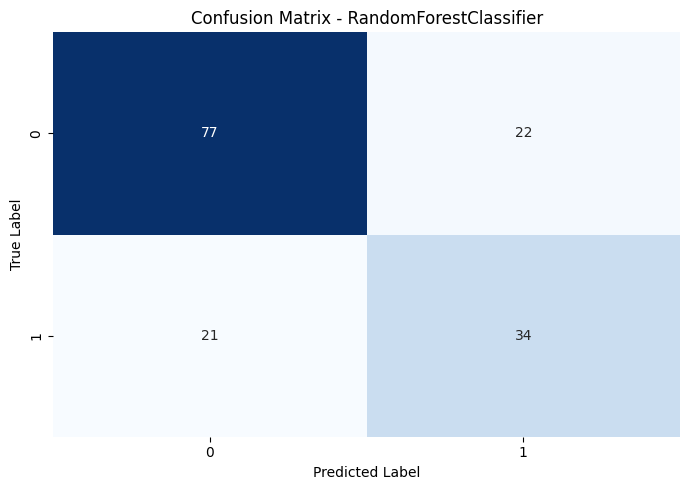

In [ ]:
import os
import pandas as pd
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier

# 1. Kaggle API Kimlik Bilgilerini Ayarlama
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Kaggle kimlik bilgileri Secrets'tan başarıyla yüklendi!")
except userdata.SecretNotFoundError:
    print("❌ HATA: Lütfen sol taraftaki '🔑' (Secrets) menüsüne KAGGLE_USERNAME ve KAGGLE_KEY değerlerini ekleyin.")

# 2. Yeni Veri Setini İndirme (Diyabet Veri Seti)
dataset_name = 'uciml/pima-indians-diabetes-database'
file_name = 'diabetes.csv'
data_dir = 'data'

print(f"\n⏳ {dataset_name} indiriliyor...")
!kaggle datasets download -d {dataset_name} --unzip -p {data_dir}

# 3. Profesyonel Pipeline'ı Çalıştırma
file_path = os.path.join(data_dir, file_name)

if os.path.exists(file_path):
    print("\n🚀 --- Pro Pipeline Başlatılıyor ---")
    df_raw = pd.read_csv(file_path)

    # İşleme
    processor = DataProcessor(df_raw)
    processor.initial_overview()
    df_clean = processor.clean_data()
    # processor.perform_eda() # EDA grafiklerini görmek isterseniz bu yorumu kaldırın

    # Hazırlık (Diyabet veri setinde hedef sütun 'Outcome' dır)
    preparer = ModelPreparer(df_clean, target_column='Outcome')
    X_train, X_test, y_train, y_test = preparer.prepare_data()

    # Eğitim ve Değerlendirme
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    trainer = ModelTrainer(model, X_train, y_train, X_test, y_test)
    trainer.train()
    trainer.evaluate()
    trainer.plot_confusion_matrix()
else:
    print(f"❌ Veri dosyası ({file_path}) bulunamadı. Lütfen Kaggle API ayarlarınızı kontrol edin.")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Kendi yüklediğiniz dosyanın adını buraya yazın
# Dosyayı sol menüden yüklediyseniz doğrudan adını yazabilirsiniz:
file_path = 'diabetes.csv' # Eğer farklı bir dosya yüklediyseniz burayı değiştirin

print(f"📂 '{file_path}' dosyası yerel ortamdan yükleniyor...")

try:
    # Kendi yüklediğimiz dosyayı okuyoruz
    df_raw = pd.read_csv(file_path)
    print("✅ Veri başarıyla yüklendi!\n")

    print("🚀 --- Pro Pipeline Başlatılıyor ---")

    # 2. İşleme (Process)
    processor = DataProcessor(df_raw)
    processor.initial_overview()
    df_clean = processor.clean_data()

    # 3. Hazırlık (Prepare)
    # ÖNEMLİ: Hedef sütun adını kendi verinize göre değiştirin
    # (Diyabet için 'Outcome', Titanic için 'Survived' gibi)
    target_col = 'Outcome'
    preparer = ModelPreparer(df_clean, target_column=target_col)
    X_train, X_test, y_train, y_test = preparer.prepare_data()

    # 4. Eğitim ve Değerlendirme (Train & Evaluate)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    trainer = ModelTrainer(model, X_train, y_train, X_test, y_test)
    trainer.train()
    trainer.evaluate()
    trainer.plot_confusion_matrix()

except FileNotFoundError:
    print(f"❌ HATA: '{file_path}' bulunamadı. Lütfen sol menüdeki 📁 (Dosyalar) ikonuna tıklayıp dosyanın tam adını doğru yazdığınızdan emin olun.")

📂 'diabetes.csv' dosyası yerel ortamdan yükleniyor...
❌ HATA: 'diabetes.csv' bulunamadı. Lütfen sol menüdeki 📁 (Dosyalar) ikonuna tıklayıp dosyanın tam adını doğru yazdığınızdan emin olun.


In [ ]:
import kagglehub
import os
import pandas as pd

# 1. Veri setini kagglehub ile indirme
print("⏳ Veri seti indiriliyor...")
path = kagglehub.dataset_download("catherinerasgaitis/mxmh-survey-results")
print("✅ Veri setinin indirildiği yol:", path)

# 2. İndirilen klasördeki CSV dosyasını bulma ve önizleme
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    file_path = os.path.join(path, csv_files[0])
    print(f"📂 Bulunan dosya okunuyor: {csv_files[0]}\n")

    # Veriyi yükleyip ilk 5 satırını gösterelim
    df_mxmh = pd.read_csv(file_path)
    display(df_mxmh.head())

    print("\n💡 İpucu: Bu veriyi Pipeline'da kullanmak için hedef sütununuzu (örneğin 'Depression' veya başka bir metrik) belirleyip ModelPreparer sınıfına verebilirsiniz.")
else:
    print("❌ Klasörde CSV dosyası bulunamadı.")

⏳ Veri seti indiriliyor...


100%|██████████| 22.4k/22.4k [00:00<00:00, 18.2MB/s]

Extracting files...
✅ Veri setinin indirildiği yol: /root/.cache/kagglehub/datasets/catherinerasgaitis/mxmh-survey-results/versions/1
📂 Bulunan dosya okunuyor: mxmh_survey_results.csv



,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.



💡 İpucu: Bu veriyi Pipeline'da kullanmak için hedef sütununuzu (örneğin 'Depression' veya başka bir metrik) belirleyip ModelPreparer sınıfına verebilirsiniz.


### 📁 Adım 1: Kendi Verinizi Yükleyin
Aşağıdaki hücreyi çalıştırarak bilgisayarınızdaki CSV dosyasını Colab ortamına yükleyebilirsiniz.

In [ ]:
from google.colab import files
import pandas as pd

print("Lütfen veri setinizi (CSV formatında) yükleyin:")
uploaded = files.upload()

if uploaded:
    # Yüklenen dosyanın adını alıyoruz
    custom_file_name = list(uploaded.keys())[0]
    print(f"\n✅ '{custom_file_name}' başarıyla yüklendi!")

    # Veriyi okuyup önizlemesini yapıyoruz
    df_custom = pd.read_csv(custom_file_name)
    display(df_custom.head())
else:
    print("\n❌ Herhangi bir dosya yüklenmedi.")

Lütfen veri setinizi (CSV formatında) yükleyin:


Saving mxmh_survey_results.csv to mxmh_survey_results.csv

✅ 'mxmh_survey_results.csv' başarıyla yüklendi!


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


### ⚙️ Adım 2: Pipeline'ı Kendi Verinizle Çalıştırın
Dosyanızı yükledikten sonra, verinizdeki **hedef sütunun (tahmin etmek istediğiniz sütunun)** adını aşağıdaki kodda güncelleyerek Pipeline'ı başlatabilirsiniz.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

print("\n🚀 --- Sentetik Veri İle Pro Pipeline Başlatılıyor ---")

# 1. Sentetik Veri Oluşturma (1000 satır, 5 özellik, 1 hedef değişken)
X_synthetic, y_synthetic = make_classification(
    n_samples=1000, n_features=5, n_informative=3, n_redundant=1, random_state=42
)

# Bunu pandas DataFrame'e dönüştürelim
df_synthetic = pd.DataFrame(X_synthetic, columns=[f'Feature_{i}' for i in range(1, 6)])
df_synthetic['Hedef_Degisken'] = y_synthetic

TARGET_COLUMN_NAME = 'Hedef_Degisken'

try:
    # 2. İşleme (Process)
    processor = DataProcessor(df_synthetic)
    processor.initial_overview()
    df_clean = processor.clean_data()

    # 3. Hazırlık (Prepare)
    preparer = ModelPreparer(df_clean, target_column=TARGET_COLUMN_NAME)
    X_train, X_test, y_train, y_test = preparer.prepare_data()

    # 4. Eğitim ve Değerlendirme (Train & Evaluate)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    trainer = ModelTrainer(model, X_train, y_train, X_test, y_test)
    trainer.train()
    trainer.evaluate()
    trainer.plot_confusion_matrix()
except NameError as e:
    print(f"\n❌ HATA: {e}\nLütfen önce 'DataProcessor', 'ModelPreparer' ve 'ModelTrainer' sınıflarının tanımlandığı en üstteki kod hücresini çalıştırın!")


🚀 --- Sentetik Veri İle Pro Pipeline Başlatılıyor ---

❌ HATA: name 'DataProcessor' is not defined
Lütfen önce 'DataProcessor', 'ModelPreparer' ve 'ModelTrainer' sınıflarının tanımlandığı en üstteki kod hücresini çalıştırın!
